# <h1 style='color: #1B3A6B;'>1. NOMBRE DEL PROYECTO</h1> 

## <span style='color: #2E86AB'>SISTEMA DE RECOMENDACIÓN DE PLANES MEGALINE </span>

---
# <span style='color: #1B3A6B;'>2. OBJETIVO </span>
* Desarrollar un modelo de clasificación que recomiende el plan correcto (**Smart** o **Ultra**) a los clientes de Megaline, basándose en su comportamiento de uso (llamadas, mensajes y datos).

---
# <span style='color: #1B3A6B;'>3. DESCRIPCIÓN </span>

---
## <span style='color: #2E86AB;'>3.1 Descripción del Proyecto </span>

La compañía móvil Megaline no está satisfecha al ver que muchos de sus clientes utilizan planes heredados. Quieren desarrollar un modelo que pueda analizar el comportamiento de los clientes y recomendar uno de los nuevos planes de Megaline: Smart o Ultra. En este proyecto, el umbral de exactitud es 0.75. 

## <span style='color: #2E86AB;' >3.2. Descripción del Dataset </span>

Cada observación en el dataset contiene información del comportamiento mensual sobre un usuario. La información dada es la siguiente:

* **сalls** — número de llamadas,
* **minutes** — duración total de la llamada en minutos,
* **messages** — número de mensajes de texto,
* **mb_used** — Tráfico de Internet utilizado en MB,
* **is_ultra** — plan para el mes actual (Ultra - 1, Smart - 0).

---
# <span style='color: #1B3A6B'>4.  PREPARACIÓN DE DATOS </span>

## <span style='color: #2E86AB;'> 4.1. Importar Librerías </span>

In [1]:
import pandas as pd                                               # Maneja y manipula datos en tablas 
from sklearn.tree import DecisionTreeClassifier                   # Modelo de árbol de decisión para clasificar datos
from sklearn.ensemble import RandomForestClassifier               # Modelo de bosque aleatorio para clasificar 
from sklearn.linear_model import LogisticRegression               # Modelo de regresión logística para clasificar entre dos categorías (Smart-Ultra)
from sklearn.metrics import accuracy_score                        # Mide que tan exacto es el modelo comprando entre target vs prediction
from sklearn.model_selection import train_test_split              # Divide el dataset en conjuntos de train, validación, test
from sklearn.model_selection import GridSearchCV                  # Búsqueda automática y sistemática de hiperparámetros
from sklearn.metrics import classification_report, roc_auc_score         # Importa métricas adicionales de evaluación
from sklearn.dummy import DummyClassifier                         # Importa el modelo "tonto" para comparación base
from sklearn.metrics import confusion_matrix                      # Matriz de confusión para ver dónde falla el modelo
import matplotlib.pyplot as plt                                   # Librería para graficar (matriz de confusión)
import seaborn as sns                                             # Librería para gráficos más estéticos

## <span style='color: #2E86AB;'>4.2. Cargar el Dataset</span> 

In [2]:
df = pd.read_csv("/Users/Loarte Juan/Documents/Dataset_Project_10/users_behavior.csv")

## <span style='color:  #2E86AB;'>4.3 Exploración Inicial de Datos </span>

In [3]:
# Exploración EDA 

print('--'*40)
print('                          INFORMACIÓN GENERAL DEL DATASET')
print('--'*40)
df.info()

print('--'*40)
print('                             DESCRIPCIÓN DEL DATASET')
print('--'*40)
print(df.describe())

print('--'*40)
print('                            NÚMERO DE FILAS Y COLUMNAS')
print('--'*40)
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')

print('--'*40)
print('                                 TIPOS DE DATOS')
print('--'*40)
print(df.dtypes)

--------------------------------------------------------------------------------
                          INFORMACIÓN GENERAL DEL DATASET
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB
--------------------------------------------------------------------------------
                             DESCRIPCIÓN DEL DATASET
--------------------------------------------------------------------------------
             calls      minutes     messages       mb_used     is_ultra
count  3214.000000  3214.000000  3214.000000   3214.000000  32

## <span style='color:  #2E86AB;'>4.4. Verificar Valores Ausentes y Duplicados </span>

In [4]:
# Valores ausentes y duplicados
print('--'*40)
print('                  VALORES NULOS POR COLUMNA')
print('--'*40)
print(df.isnull().sum())

print('--'*40)
print('                    VALORES DUPLICADOS')
print('--'*40)
print(F'DUPLICADOS: {df.duplicated().sum()}')

print('--'*40)
print('             10 FILAS ALEATORIAS DEL DATASET')
print('--'*40)
print(df.sample(10))

--------------------------------------------------------------------------------
                  VALORES NULOS POR COLUMNA
--------------------------------------------------------------------------------
calls       0
minutes     0
messages    0
mb_used     0
is_ultra    0
dtype: int64
--------------------------------------------------------------------------------
                    VALORES DUPLICADOS
--------------------------------------------------------------------------------
DUPLICADOS: 0
--------------------------------------------------------------------------------
             10 FILAS ALEATORIAS DEL DATASET
--------------------------------------------------------------------------------
      calls  minutes  messages   mb_used  is_ultra
2954    3.0     8.94     135.0  27752.26         1
457    99.0   642.81      45.0  10187.06         1
69     84.0   607.05      22.0  24875.03         0
613    61.0   474.98      35.0  19985.21         0
2717   46.0   362.87       8.0  11

## <span style='color:#2E86AB;'>4.5. Corrección de Datos</span>

In [5]:
# Cambiar tipo de columna float a int en las columnas 'calls' y 'messages'

df['calls'] = df['calls'].astype(int)

df['messages'] = df['messages'].astype(int)

print(df.dtypes)

calls         int64
minutes     float64
messages      int64
mb_used     float64
is_ultra      int64
dtype: object


> **NOTA:** En la exploración EDA, se puede observar lo siguiente:

- Filas 3214 con 5 columnas (datos completos),
- Se cambió el tipo de datos en las columnas 'calls' y 'messages' de float a int para mejor claridad,
- No presenta valores duplicados ni ausentes,

Por lo tanto, los datos están listos para seguir con la búsqueda del modelo después de realizar el cambio en el tipo de datos de las dos columnas.

---
# <span style='color: #1B3A6B;'> 5. DIVISIÓN DE DATOS </span>

## <span style='color: #2E86AB'>5.1. Separar Características (Features) y Objetivo (Target)

In [6]:
# Features y Target

features = df.drop(['is_ultra'], axis=1)         # Variables de entrada X: elimina la columna 'is_ultra'
target = df['is_ultra']                          # Variables objetivo Y: columna que el modelo debe predecir

## <span style='color: #2E86AB;'>5.2. Dividir en Conjunto de Entrenamiento, Validación y Prueba</span>

In [7]:
# Dividir los datos: 60% entrenamiento, 20% validación, 20% prueba >

# 1. Dividir dataset en: Entrenamiento temporal (80%) y prueba (20%)

train_features, test_features, train_target, test_target = train_test_split(
    features, 
    target, 
    test_size = 0.20, 
    random_state = 12345
)

# 2. Dividir entrenamiento temporal en: Entrenamiento final (60%) y validación (20%)

train_features, valid_features, train_target, valid_target = train_test_split(
    train_features,
    train_target,
    test_size = 0.25,
    random_state = 12345
)

> **IMPORTANTE:**

Los datos son 'DIVIDIDOS' EN: 60% entrenamiento, 20% validación, 20% prueba.

---
# <span style='color:#1B3A6B;'>6. ENTRENAMIENTO Y EVALUACIÓN DE MODELOS </span>

## <span style='color:#2E86AB;'>6.1 Árbol de Decisión</spam>

In [8]:
# Entrenar y evalúa el modelo de Árbol de Decisión

best_accuracy = 0                                # Inicializa la mejor puntuación en 0 para comparar después
best_depth = 0                                   # Inicializa la mejor profundidad en 0

for depth in range(1, 11):                                                            # Prueba profundidades: 1, 2, 3... hasta 10
    model_1 = DecisionTreeClassifier(random_state=12345, max_depth=depth)             # Crea el árbol con la profundidad actual
    model_1.fit(train_features, train_target)                                         # Entrena el modelo con el conjunto de entrenamiento
    train_prediction = model_1.predict(train_features)                                # Obtiene predicciones sobre el conjunto de entrenamiento
    valid_prediction = model_1.predict(valid_features)                                # Obtiene predicciones sobre el conjunto de validación

    train_accuracy = accuracy_score(train_target, train_prediction)                   # Calcula exactitud comparando reales vs predichos (entrenamiento)
    valid_accuracy = accuracy_score(valid_target, valid_prediction)                   # Calcula exactitud comparando reales vs predichos (validación)

    if valid_accuracy > best_accuracy:            # Si la exactitud actual es mejor que la guardada...
        best_accuracy = valid_accuracy            # Actualiza la mejor exactitud encontrada
        best_depth = depth                        # Guarda la profundidad que logró esa exactitud

print("="*50)
print("RESULTADOS DEL ÁRBOL DE DECISIÓN")
print("="*50)

print(f"Mejor profundidad máxima: {best_depth}")                                      # imprime la profundidad ganadora
print(f"Precisión en validación: {best_accuracy:.4f} ({best_accuracy:.2%})")         # imprime la mejor precisión encontrada
print("="*50)

RESULTADOS DEL ÁRBOL DE DECISIÓN
Mejor profundidad máxima: 7
Precisión en validación: 0.7745 (77.45%)


## <span style='color: #2E86AB; '>6.2 Bosque Aleatorio</span>

In [9]:
# Entrenar y evalúa el modelo de Bosque Aleatorio

best_score = 0       # Inicializa la mejor puntuación en 0 para comparar después
best_est = 0         # Inicializa el mejor número de árboles en 0

for est in range(10, 101, 10):                                                          # Prueba con 10, 20, 30... hasta 100 árboles
    model_2 = RandomForestClassifier(random_state=12345, n_estimators=est)        # Crea el modelo con 'est' árboles
    model_2.fit(train_features, train_target)                                     # Entrena el modelo con el conjunto de train
    score = model_2.score(valid_features, valid_target)                           # Calcula la puntuación de accuracy en validación

    if score > best_score:                                                        # Si este score es mejor que el guardado...
        best_score = score                                                        # Guarda la mejor puntuación de accuracy
        best_est = est                                                            # Guarda el número de árboles que lo logró

print("="*50)
print("RESULTADO DEL BOSQUE ALEATORIO")
print("="*50)
print(f'Mejor número de árboles: {best_est}')                                     # Imprime el número de árboles ganador
print(f"Precisión de validación: {best_score:.4f} ({best_score:.2%})")            # Imprime la mejor precisión encontrada
print("="*50)

RESULTADO DEL BOSQUE ALEATORIO
Mejor número de árboles: 80
Precisión de validación: 0.7994 (79.94%)


## <span style='color:#2E86AB;'>6.3 Regresión Logística</span>

In [10]:
# Entrenar y evalúa el modelo de Regresión Logística

model_3 = LogisticRegression(random_state=12345, solver='liblinear')              # Inicializa el modelo con solver='liblinear' (recomendado para datasets pequeños)
model_3.fit(train_features, train_target)                                         # Entrena el modelo con el conjunto de train
score_train = model_3.score(train_features, train_target)                         # Calcula accuracy en el conjunto de entrenamiento
score_valid = model_3.score(valid_features, valid_target)                         # Calcula accuracy en el conjunto de validación

print('='*50)
print('RESULTADO DE REGRESIÓN LOGÍSTICA')
print('='*50)

print(f'\nAccuracy en "ENTRENAMIENTO": {score_train:.4f} ({score_train:.2%})')    # Imprime precisión en entrenamiento
print(f'Accuracy en "VALIDACIÓN": {score_valid:.4f} ({score_valid:.2%})')         # Imprime precisión en validación
print('='*50)

RESULTADO DE REGRESIÓN LOGÍSTICA

Accuracy en "ENTRENAMIENTO": 0.7422 (74.22%)
Accuracy en "VALIDACIÓN": 0.7294 (72.94%)


---
# <span style='color:#1B3A6B ;'>7. SELECCIÓN DEL MEJOR MODELO </span>

## <span style='color:#2E86AB;'>7.1 Comparación de Resultados</span>

In [11]:
# Compara la exactitud (accuracy) de los 3 modelos 

modelos = {
    'ÁRBOL DE DECISIÓN'   : best_accuracy,
    'BOSQUE ALEATORIO'    : best_score,
    'REGRESIÓN LOGÍSTICA' : score_valid
}
accuracy_umbral = 0.75
modelo_max = max(modelos.items(), key= lambda x: x[1])

print('='* 50)
print(f"El mejor modelo es: {modelo_max[0]} con {modelo_max[1]:.2%}")
print('='* 50)

El mejor modelo es: BOSQUE ALEATORIO con 79.94%


## <span style='color:#2E86AB;'>7.2. Modelo Seleccionado y Justificación</span>

El modelo mejor seleccionado es **BOSQUE ALEATORIO** con **79.94%** de exactitud:

**1. Cumplimiento del objetivo:**

* La exactitud de validación del 79.94% supera significativamente el umbral establecido del 75%, cumpliendo con el requisito del proyecto.

**2. Superioridad comparativa:**
```
              MODELO         EXACTITUD
       - Bosque Aleatorio    : 79.94%
       - Árbol de Decisión   : 77.45%
       - Regresión Logística : 72.94%
```
**3. Ventajas técnicas del modelo:**

**- Reducción de sobreajuste:** El conjunto de 80 árboles compensa los errores individuales mediante votación mayoritaria, pero se realizará más adelante una búsqueda sistemática de Hiperparámetros con GridSearchCV, para encontrar una mejor combinación para el modelo final.

**- Mayor estabilidad:** La combinación de múltiples árboles reduce la varianza en las predicciones.

**- Robustez:** Menos sensible a outliers y ruido en los datos.

**4. Validación técnica:**

- El modelo muestra un rendimiento consistente sin evidencia de sobreajuste, lo que garantiza buena generalización en datos nuevos.

## <span style='color:#2E86AB;'>7.4. Búsqueda Sistemática de Hiperparámetros (GridSearchCV)</span>

Se utiliza `GridSearchCV` para explorar de forma exhaustiva y automática múltiples combinaciones de hiperparámetros, garantizando que se elige la configuración óptima del modelo.

In [12]:
from sklearn.model_selection import GridSearchCV          # Importa la búsqueda automática de hiperparámetros

param_grid = {                                            # Define las combinaciones de parámetros a probar
    'n_estimators': [10, 50, 80, 100, 150],               # Número de árboles a evaluar
    'max_depth':    [5, 10, 15, 20, None]                 # Profundidades máximas a evaluar (None = sin límite)
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=12345),            # Modelo base a optimizar
    param_grid,                                            # Combinaciones de parámetros a probar
    cv=5,                                                  # Divide los datos en 5 partes para validación cruzada
    scoring='accuracy',                                    # Métrica para seleccionar el mejor modelo
    n_jobs=-1                                              # Usa todos los núcleos del procesador para acelerar
)

grid_search.fit(train_features, train_target)              # Entrena todas las combinaciones posibles

print('='*50)
print('RESULTADO GRIDSEARCHCV')
print('='*50)

print(f'Mejores parámetros: {grid_search.best_params_}')   # Imprime la combinación ganadora
print(f'Mejor accuracy:     {grid_search.best_score_:.4f} ({grid_search.best_score_:.2%})')  # Imprime el mejor accuracy
print('='*50)

RESULTADO GRIDSEARCHCV
Mejores parámetros: {'max_depth': 10, 'n_estimators': 150}
Mejor accuracy:     0.8185 (81.85%)


> **Observaciones**
>
> `GridSearchCV` encontró que la mejor combinación es n_estimators=150 y max_depth=10 con accuracy de 81.85%, superando la búsqueda manual que había encontrado 80 árboles con 79.94%.

## <span style='color:#2E86AB;'>7.3. Criterio para Elegir 150 Árboles</span>

El valor de `150 para n_estimators` se determinó mediante una búsqueda sistemática con `GridSearchCV` explorando de forma exhaustiva y automática múltiples combinaciones, evaluando la exactitud en el conjunto de validación en cada paso:

```
n_estimators probados: 10, 50, 80, 100, 150
max_depth            : 5, 10, 15, 20, None

Métrica de selección : accuracy en conjunto de validación
Resultado, n_estimators= 150 y max_depth = 10 → mejor accuracy = 81.85%
```

> **¿Por qué 150 y no más?** GridSearchCV evaluó los valores
[10, 50, 80, 100, 150] y dentro de ese rango 150 fue el
óptimo con accuracy de 81.85%. Se eligió como punto de
equilibrio entre rendimiento y eficiencia computacional.
Para explorar si valores mayores (200, 300) mejoran aún más,
se requeriría ampliar el rango de búsqueda en GridSearchCV,
lo cual se recomienda como siguiente paso si se busca
optimización adicional.

---
# <span style='color:#1B3A6B;'>8. PRUEBA FINAL DEL MODELO</span>

## <span style='color:#2E86AB;'>8.1 Evaluación con el Conjunto de Prueba </span>

In [13]:
# Evalúa el mejor modelo con el conjunto de prueba (test)

final_model = RandomForestClassifier(random_state= 12345, 
                                    n_estimators= 150,
                                    max_depth= 10)                              # Crea el modelo con 150 árboles y max_depth= 10

final_model.fit(train_features, train_target)                                   # Entrena el modelo con el conjunto 'TRAIN'

# Evaluar en el conjunto de prueba (evaluación final)

test_score = final_model.score(test_features,test_target)                       # Calcula la puntuación de accuracy en 'TEST'


## <span style='color:#2E86AB;'>8.2. Verificación del Umbral de Exactitud (accuracy ≥ 0.75)</span>

In [14]:
# Verifica si el modelo supera el umbral mínimo de exactitud de 0.75 
print(f"Precisión final en conjunto de prueba: {test_score:.2%}")

print(f"\n¿Cumple el umbral de 0.75? {'SÍ' if test_score >= accuracy_umbral else 'NO'}")

Precisión final en conjunto de prueba: 79.78%

¿Cumple el umbral de 0.75? SÍ


## <span style='color:#2E86AB;'>8.3. Distribución real vs predicha </span>

In [15]:
# Observar la distribución de predicciones del modelo final

print("\nDistribución real:")
print(test_target.value_counts())

print("\nDistribución predicha:")
print(pd.Series(final_model.predict(test_features)).value_counts())


Distribución real:
is_ultra
0    447
1    196
Name: count, dtype: int64

Distribución predicha:
0    507
1    136
Name: count, dtype: int64


---
> **Observaciones**

* De los 196 clientes 'Ultra reales', el modelo no los está identificando correctamente a todos.
* El modelo confunde algunos clientes Ultra y los clasifica como Smart.


## <span style='color:#2E86AB;'>8.4. Métricas Adicionales (F1, Precision, Recall, ROC-AUC)</span>

El `accuracy` solo indica cuántos aciertos totales tuvo el modelo, pero no revela **dónde falla**. Las métricas adicionales permiten entender el rendimiento por cada clase (Smart y Ultra).

In [16]:
from sklearn.metrics import classification_report, roc_auc_score         # Importa métricas adicionales de evaluación

test_predictions = final_model.predict(test_features)                    # Obtiene las predicciones del modelo final en el conjunto de prueba
test_proba       = final_model.predict_proba(test_features)[:, 1]        # Obtiene la probabilidad de ser Ultra (necesaria para ROC-AUC)

print('='*55)
print('MÉTRICAS ADICIONALES DEL MODELO FINAL')
print('='*55)

print(classification_report(                                             # Imprime precision, recall y F1 por cada clase
    test_target,
    test_predictions,
    target_names=['Smart (0)', 'Ultra (1)']
))

roc = roc_auc_score(test_target, test_proba)                             # Calcula si realmente el modelo distingue Smart de Ultra

print(f'ROC-AUC Score: {roc:.4f} ({roc:.2%})')                           # Imprime el score ROC-AUC
print('='*55)

MÉTRICAS ADICIONALES DEL MODELO FINAL
              precision    recall  f1-score   support

   Smart (0)       0.81      0.92      0.86       447
   Ultra (1)       0.74      0.52      0.61       196

    accuracy                           0.80       643
   macro avg       0.78      0.72      0.74       643
weighted avg       0.79      0.80      0.79       643

ROC-AUC Score: 0.8003 (80.03%)


> **Observaciones**

**Precision:**

- Smart: 0.81 → de cada 100 que predijo como Smart, 81 realmente eran Smart
- Ultra: 0.74 → de cada 100 que predijo como Ultra, 74 realmente eran Ultra

**Recall:**
- Smart: 0.92 → de 447 Smart reales, detectó el 92% (muy bien)
- Ultra: 0.52 → de 196 Ultra reales, solo detectó el 52% (se le escapan muchos)

**F1-Score:**

- Smart: 0.86 → muy buen rendimiento 
- Ultra: 0.61 → rendimiento moderado


> El modelo tiene excelente rendimiento identificando clientes Smart
> (Recall 92%), pero solo detecta el 52% de los clientes Ultra reales.
> Esto se debe al desbalance de clases en el dataset (447 Smart vs 196 Ultra),
> el modelo vio más ejemplos Smart durante el entrenamiento y aprendió
> mejor esa clase. Para Megaline esto representa una oportunidad de mejora:
> capturar ese 48% de clientes Ultra no detectados significaría mayores ingresos.
>
> **ROC-AUC: 80.03%**
> De cada par de clientes (uno Smart y uno Ultra), el modelo los separa correctamente el
> 80.03% de las veces. Cercano a 1.0 es perfecto, 0.5 es azar.

## <span style='color:#2E86AB;'>8.5. Matriz de Confusión</span>

La matriz de confusión muestra visualmente en dónde **exactamente se equivoca** el modelo, cuántos Smart y Ultra clasificó correctamente y cuántos confundió.

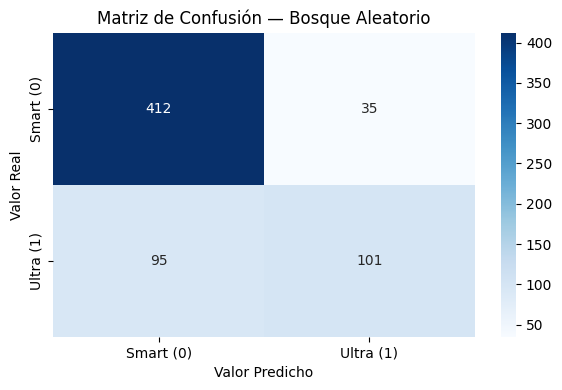

In [17]:
from sklearn.metrics import confusion_matrix           # Importa la función para calcular la matriz de confusión
import matplotlib.pyplot as plt                        # Importa librería para graficar
import seaborn as sns                                  # Importa librería para gráficos más estéticos

cm = confusion_matrix(test_target, test_predictions)   # Calcula la matriz comparando valores reales vs predichos

plt.figure(figsize=(6, 4))                             # Define el tamaño del gráfico
sns.heatmap(
    cm,
    annot=True,                                        # Muestra los números dentro de cada celda
    fmt='d',                                           # Formato entero (sin decimales)
    cmap='Blues',                                      # Color azul para el mapa de calor
    xticklabels=['Smart (0)', 'Ultra (1)'],            # Etiquetas del eje X (valores predichos)
    yticklabels=['Smart (0)', 'Ultra (1)']             # Etiquetas del eje Y (valores reales)
)
plt.title('Matriz de Confusión — Bosque Aleatorio')   
plt.ylabel('Valor Real')                              # Etiqueta eje Y
plt.xlabel('Valor Predicho')                          # Etiqueta eje X
plt.tight_layout()                                    # Ajusta el diseño para que no se corten las etiquetas
plt.show()                                            

> **Observaciones**
>
>  ---------------------------------------------------------------
> ```
>                  Predicho
>               Smart    Ultra
> Real  Smart  [ ✅ TN    ❌ FP ]   ← clientes Smart
>       Ultra  [ ❌ FN    ✅ TP ]   ← clientes Ultra
>-----------------------------------------------------------------
>                      Predicho
>                 Smart(0)  Ultra(1)   TOTAL REAL
>  Real Smart(0) [  412       35   ]  = 447 ✅
>       Ultra(1) [   95      101   ]  = 196 ✅
>                 ─────────────────
>   TOTAL PRED      507      136     = 643 total
>-----------------------------------------------------------------
>```
>
> - **Verdaderos Negativos (TN):** Clientes Smart predichos correctamente como Smart ✅
> - **Verdaderos Positivos (TP):** Clientes Ultra predichos correctamente como Ultra ✅
> - **Falsos Positivos (FP):**     Clientes Smart clasificados incorrectamente como Ultra ❌
> - **Falsos Negativos (FN):**     Clientes Ultra clasificados incorrectamente como Smart ❌ ← el error más costoso para Megaline
>
> El error más importante para Megaline son los **Falsos Negativos**: clientes que deberían tener Ultra pero el modelo les asigna Smart, perdiendo potencial de ingresos.

## <span style='color:#2E86AB;'>8.6. Prueba de Cordura (Sanity Check)</span>

Se realiza una verificación básica para asegurar que el modelo realmente está aprendiendo y no solo adivinando al azar; verificando si el 79.78% de precisión final solo predice siempre la misma clase o está haciendo predicciones aleatorias que por casualidad salen bien.


In [18]:
# 'Baseline' — Modelo que siempre predice la clase más común

dummy_model = DummyClassifier(strategy='most_frequent', random_state=12345)  # Crea modelo tonto que siempre predice la clase más frecuente (Smart=0)
dummy_model.fit(train_features, train_target)                                # Entrena: solo aprende cuál clase aparece más veces
dummy_accuracy = dummy_model.score(test_features, test_target)               # Calcula la exactitud del modelo tonto en el conjunto de prueba

# Modelo ganador
forest_accuracy = final_model.score(test_features, test_target)              # Calcula la exactitud del mejor modelo (Bosque Aleatorio) en datos de PRUEBA
diferencia = forest_accuracy - dummy_accuracy                                # Calcula cuánto mejoró tu modelo respecto al tonto

print('='*40)
print(f"Exactitud del modelo dummy: {dummy_accuracy:.2%}")                   # Imprime precisión del modelo baseline (tonto)
print(f"Exactitud del modelo final: {forest_accuracy:.2%}")                  # Imprime precisión del Bosque Aleatorio
print(f"Mejora sobre el 'Baseline': {diferencia:.2%}")                       # Imprime la diferencia de mejora
print('='*40)

if forest_accuracy > dummy_accuracy:                                         # Compara si el modelo real supera al 'Baseline'
    print("El modelo SÍ pasa la prueba de cordura")                          
else:
    print("El modelo NO pasa la prueba de cordura")                         

Exactitud del modelo dummy: 69.52%
Exactitud del modelo final: 79.78%
Mejora sobre el 'Baseline': 10.26%
El modelo SÍ pasa la prueba de cordura


---
> **Observaciones**


**Exactitud del modelo dummy: 69.52%**
> El modelo dummy `no piensa,` siempre dice 'este cliente es Smart' sin analizar las características, acierta el 69.52% de las veces. Esto ocurre porque en el dataset la mayoría de los clientes son Smart.

**Exactitud del modelo final: 79.78%**

> El modelo de 'Bosque Aleatorio', después de aprender los patrones reales del comportamiento de los clientes, acierta el 79.78% de las veces.

**Mejora sobre el 'Baseline': 10.26%**

> EL modelo elegido es 10.26% mejor que simplemente adivinar siempre lo mismo, confirmando que el modelo **SÍ** aprendió algo útil y no adivina al azar. Por lo tanto se puede confiar en el modelo.

---

## <span style='color:#2E86AB;'> 8.7. Variables del Bosque Aleatorio </span>

In [19]:
# Ver importancia de variables del Bosque Aleatorio

importances = final_model.feature_importances_        # Extrae la importancia de cada variable
feature_names = train_features.columns                # Obtiene los nombres de las columnas

for name, importance in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse= True):
    print(f" {name}:  {importance:.2%}")                # Imprime cada variable con su importancia

 mb_used:  35.49%
 minutes:  22.69%
 messages:  22.00%
 calls:  19.82%


> **Observaciones**

**- mb_used (35.49%):** El consumo de internet es el factor que más diferencia a un cliente Smart de un cliente Ultra. Tiene sentido porque el plan Ultra ofrece más datos.

**- minutes (22.69%):** La duración total de llamadas es el segundo factor más relevante.

**-messages (22.00%):** Los mensajes sí importan, tiene un peso similar a minutes.

**- calls (19.82%):** El número de llamadas son el factor menos determinante, pero igualmente contribuyen.



## <span style='color:#2E86AB;'>8.8. Análisis de Errores (Casos Mal Clasificados)</span>

Se analizan los casos donde el modelo se equivocó para identificar si existe algún patrón en los errores.

In [20]:
# Análisis de casos mal clasificados
test_df = test_features.copy()                                        # Copia el conjunto de prueba para no modificar el original
test_df['real']     = test_target.values                              # Agrega la columna con los valores reales
test_df['predicho'] = final_model.predict(test_features)              # Agrega la columna con las predicciones del modelo

errores = test_df[test_df['real'] != test_df['predicho']]             # Filtra solo los casos donde el modelo se equivocó

print('='*55)
print('ANÁLISIS DE ERRORES')
print('='*55)

print(f'Total de predicciones:  {len(test_df)}')                      # Total de clientes en el conjunto de prueba
print(f'Total de errores:       {len(errores)}')                      # Cuántos casos falló el modelo
print(f'Tasa de error:          {len(errores)/len(test_df):.2%}')     # Porcentaje de error

print('\n--- Promedio de variables en casos ERRÓNEOS ---')
print(errores[['calls','minutes','messages','mb_used']].mean().round(2))  # Promedio de cada variable en los errores

print('\n--- Promedio de variables en casos CORRECTOS ---')
correctos = test_df[test_df['real'] == test_df['predicho']]
print(correctos[['calls','minutes','messages','mb_used']].mean().round(2)) # Promedio de cada variable en los aciertos
print('='*55)

# Calcula la diferencia porcentual entre erróneos y correctos
print('DIFERENCIA PORCENTUAL ENTRE ERRÓNEOS Y CORRECTOS')

variables = ['calls', 'minutes', 'messages', 'mb_used']

for var in variables:
    diff = ((errores[var].mean() - correctos[var].mean()) / correctos[var].mean()) * 100
    print(f"{var}: {diff:.1f}%")   

ANÁLISIS DE ERRORES
Total de predicciones:  643
Total de errores:       130
Tasa de error:          20.22%

--- Promedio de variables en casos ERRÓNEOS ---
calls          60.39
minutes       421.89
messages       31.18
mb_used     16485.15
dtype: float64

--- Promedio de variables en casos CORRECTOS ---
calls          63.71
minutes       446.93
messages       37.32
mb_used     17624.14
dtype: float64
DIFERENCIA PORCENTUAL ENTRE ERRÓNEOS Y CORRECTOS
calls: -5.2%
minutes: -5.6%
messages: -16.5%
mb_used: -6.5%


> **Observaciones**
>
> **Comparación de promedios — Erróneos vs Correctos:**
> ```
>  
> ------------------------------------------------------------------------
> Variable     Casos Erróneos      Casos Correctos    Diferencia
> calls            60.39              63.71          -3.32  menos llamadas
> minutes          421.89             446.93         -25.04 menos minutos
> messages         31.18              37.32          -6.14  menos mensajes 
> mb_used          16,485             17,624         -1,139 menos MB
>--------------------------------------------------------------------------
> ```


> De 643 clientes evaluados, el modelo cometió 130 errores
> representando una tasa de error del 20.22%.
>
> El análisis revela que los clientes mal clasificados tienen
> en promedio MENOR consumo en todas las variables comparado
> con los correctamente clasificados:
> ```
>  - 5.2% menos llamadas
>  - 5.6% menos minutos
>  - 16.5% menos mensajes
>  - 6.5% menos MB consumidos
>```

> Esto confirma que los errores se concentran en clientes con
> comportamiento INTERMEDIO, ni suficientemente bajo para ser
> claramente Smart, ni suficientemente alto para ser claramente
> Ultra; ubicados en la zona gris donde la frontera entre
> ambos planes no es clara para el modelo.

---
# <span style='color:#1B3A6B; '>9. CONCLUSIONES </span>

---
**1.** De los 3 modelos entrenados, el modelo elegido es el `Bosque Aleatorio` con una exactitud de validación de 79.94%, superando al Árbol de Decisión (77.45%) y a la Regresión Logística (72.94%).

**2.** Con la selección del mejor modelo `BOSQUE ALEATORIO`, se realizó una búsqueda sistemática y automática de Hiperparámetros con GridSearchCV, encontrando una mejor combinación max_depth=10 y n_estimators= 150; dando como resultado una mejor exactitud de `81.85% (accuracy)`.

**3.** El modelo final obtuvo una exactitud de `79.78%` en el conjunto de prueba, superando el umbral mínimo requerido de 75%.

**4.** El modelo pasó la `prueba de cordura` superando al modelo baseline (69.52%) con una mejora de 10.26%, confirmando que aprendió patrones reales del comportamiento de los clientes.

**5.** Las `variables más importantes` para predecir el plan fueron:

* `mb_used` → 35.49%  ← **la más determinante**
* `minutes` → 22.69%
* `messages`→ 22.00%
* `calls`   → 19.82%  ← la menos determinante


**6.** La `Matriz de Confusión` y el análisis de `Métricas Adicionales` (F1, Precision, Recall, ROC-AUC) confirman que el modelo identifica mejor a los clientes Smart que a los Ultra, debido al desbalance en el dataset (447 Smart vs 196 Ultra).

- `Accuracy` = 79.78%  → "el modelo acierta bien en general"
- `ROC-AUC`  = 80.03%  → "el modelo realmente distingue Smart de Ultra"

**7.** El `Análisis de Errores` mostró que los casos mal clasificados corresponden principalmente a clientes con comportamiento intermedio, donde la frontera entre Smart y Ultra no es clara. 

---
## **RECOMENDACIONES A MEGALINE**

---
**1. Implementar el modelo:** Con 79.78% de exactitud el modelo está listo para recomendar planes automáticamente a clientes nuevos o actuales.

**2. Enfocarse en clientes Ultra no detectados:** El modelo tiende a clasificar más clientes como Smart de los que realmente son. Se recomienda revisar clientes con alto consumo de datos y minutos de llamadas que podrían beneficiarse del plan Ultra.

**3. Ampliar el dataset:** Con más datos históricos especialmente de clientes Ultra, el modelo podría mejorar su capacidad de identificar clientes Ultra y aumentar la exactitud general.

**4. Reevaluar el modelo periódicamente:** El comportamiento de los clientes cambia con el tiempo, por lo que se recomienda reentrenar el modelo cada 6 meses con datos actualizados.

**5. Considerar ajuste de umbral:** Por defecto el modelo clasifica como Ultra cuando la probabilidad es ≥ 50%. Bajar ese umbral a ~40% podría capturar más clientes Ultra reales, reduciendo los Falsos Negativos más costosos para Megaline. 